<a href="https://colab.research.google.com/github/Rocio2796/FinalProyect/blob/main/FinalProyect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Objetivo: Crear un sistema que analice los patrones de comportamiento diario de una
persona mayor que vive sola para predecir riesgos físicos (caídas) o emocionales
(aislamiento).

## Enfoque 1: Árboles de Decisión para el riesgo de aislamiento social

Vamos a empezar con la implementación de un modelo de Árbol de Decisión para clasificar el nivel de riesgo de aislamiento social (Bajo, Medio, Alto). Para ello, crearemos un dataset sintético que represente las variables mencionadas en el contexto.

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Crear un dataset sintético
data = {
    'llamadas_semana': np.random.randint(0, 10, 100), # Número de llamadas telefónicas a la semana
    'visitas_recibidas': np.random.randint(0, 5, 100), # Visitas recibidas
    'salido_de_casa': np.random.choice([0, 1], 100), # 0 para No, 1 para Sí
    'riesgo_aislamiento': ['Bajo'] * 50 + ['Medio'] * 30 + ['Alto'] * 20 # Nivel de riesgo
}

df_isolation = pd.DataFrame(data)

# Ajustar el riesgo_aislamiento basado en las variables sintéticas
# Por ejemplo, más llamadas/visitas/salidas -> menor riesgo
for i in range(len(df_isolation)):
    if df_isolation.loc[i, 'llamadas_semana'] < 2 and df_isolation.loc[i, 'visitas_recibidas'] < 1 and df_isolation.loc[i, 'salido_de_casa'] == 0:
        df_isolation.loc[i, 'riesgo_aislamiento'] = 'Alto'
    elif df_isolation.loc[i, 'llamadas_semana'] < 4 or df_isolation.loc[i, 'visitas_recibidas'] < 2:
        if df_isolation.loc[i, 'riesgo_aislamiento'] == 'Bajo': # Only upgrade if it was 'Bajo', avoid downgrading from 'Alto'
            df_isolation.loc[i, 'riesgo_aislamiento'] = 'Medio'

# Mostrar las primeras filas del dataset
display(df_isolation.head())
# Mostrar la distribución de la variable objetivo
display(df_isolation['riesgo_aislamiento'].value_counts())


,llamadas_semana,visitas_recibidas,salido_de_casa,riesgo_aislamiento
0,1,2,1,Medio
1,8,2,1,Bajo
2,9,2,0,Bajo
3,9,2,0,Bajo
4,7,3,1,Bajo


,count
riesgo_aislamiento,
Medio,56
Bajo,23
Alto,21


### Preprocesamiento de Datos

Convertimos las variables categóricas a numéricas para el modelo y dividimos el dataset en conjuntos de entrenamiento y prueba.

In [4]:
# Mapear la variable objetivo a valores numéricos
risk_mapping = {'Bajo': 0, 'Medio': 1, 'Alto': 2}
df_isolation['riesgo_aislamiento_encoded'] = df_isolation['riesgo_aislamiento'].map(risk_mapping)

# Definir las características (X) y la variable objetivo (y)
X = df_isolation[['llamadas_semana', 'visitas_recibidas', 'salido_de_casa']]
y = df_isolation['riesgo_aislamiento_encoded']

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Dimensiones del conjunto de entrenamiento:", X_train.shape, y_train.shape)
print("Dimensiones del conjunto de prueba:", X_test.shape, y_test.shape)

Dimensiones del conjunto de entrenamiento: (70, 3) (70,)
Dimensiones del conjunto de prueba: (30, 3) (30,)


### Entrenamiento del Modelo de Árbol de Decisión

Entrenamos un clasificador de Árbol de Decisión con los datos de entrenamiento.

In [6]:
# Inicializar y entrenar el modelo de Árbol de Decisión con una profundidad máxima limitada para mejorar la interpretabilidad
dtree_model = DecisionTreeClassifier(random_state=42, max_depth=3)
dtree_model.fit(X_train, y_train)

print("Modelo de Árbol de Decisión entrenado con max_depth=3.")

Modelo de Árbol de Decisión entrenado con max_depth=3.


### Evaluación del Modelo

Evaluamos el rendimiento del modelo en el conjunto de prueba y visualizamos el árbol de decisión.


Precisión del modelo: 0.63

Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.47      1.00      0.64         7
       Medio       0.86      0.71      0.77        17
        Alto       0.00      0.00      0.00         6

    accuracy                           0.63        30
   macro avg       0.44      0.57      0.47        30
weighted avg       0.59      0.63      0.59        30



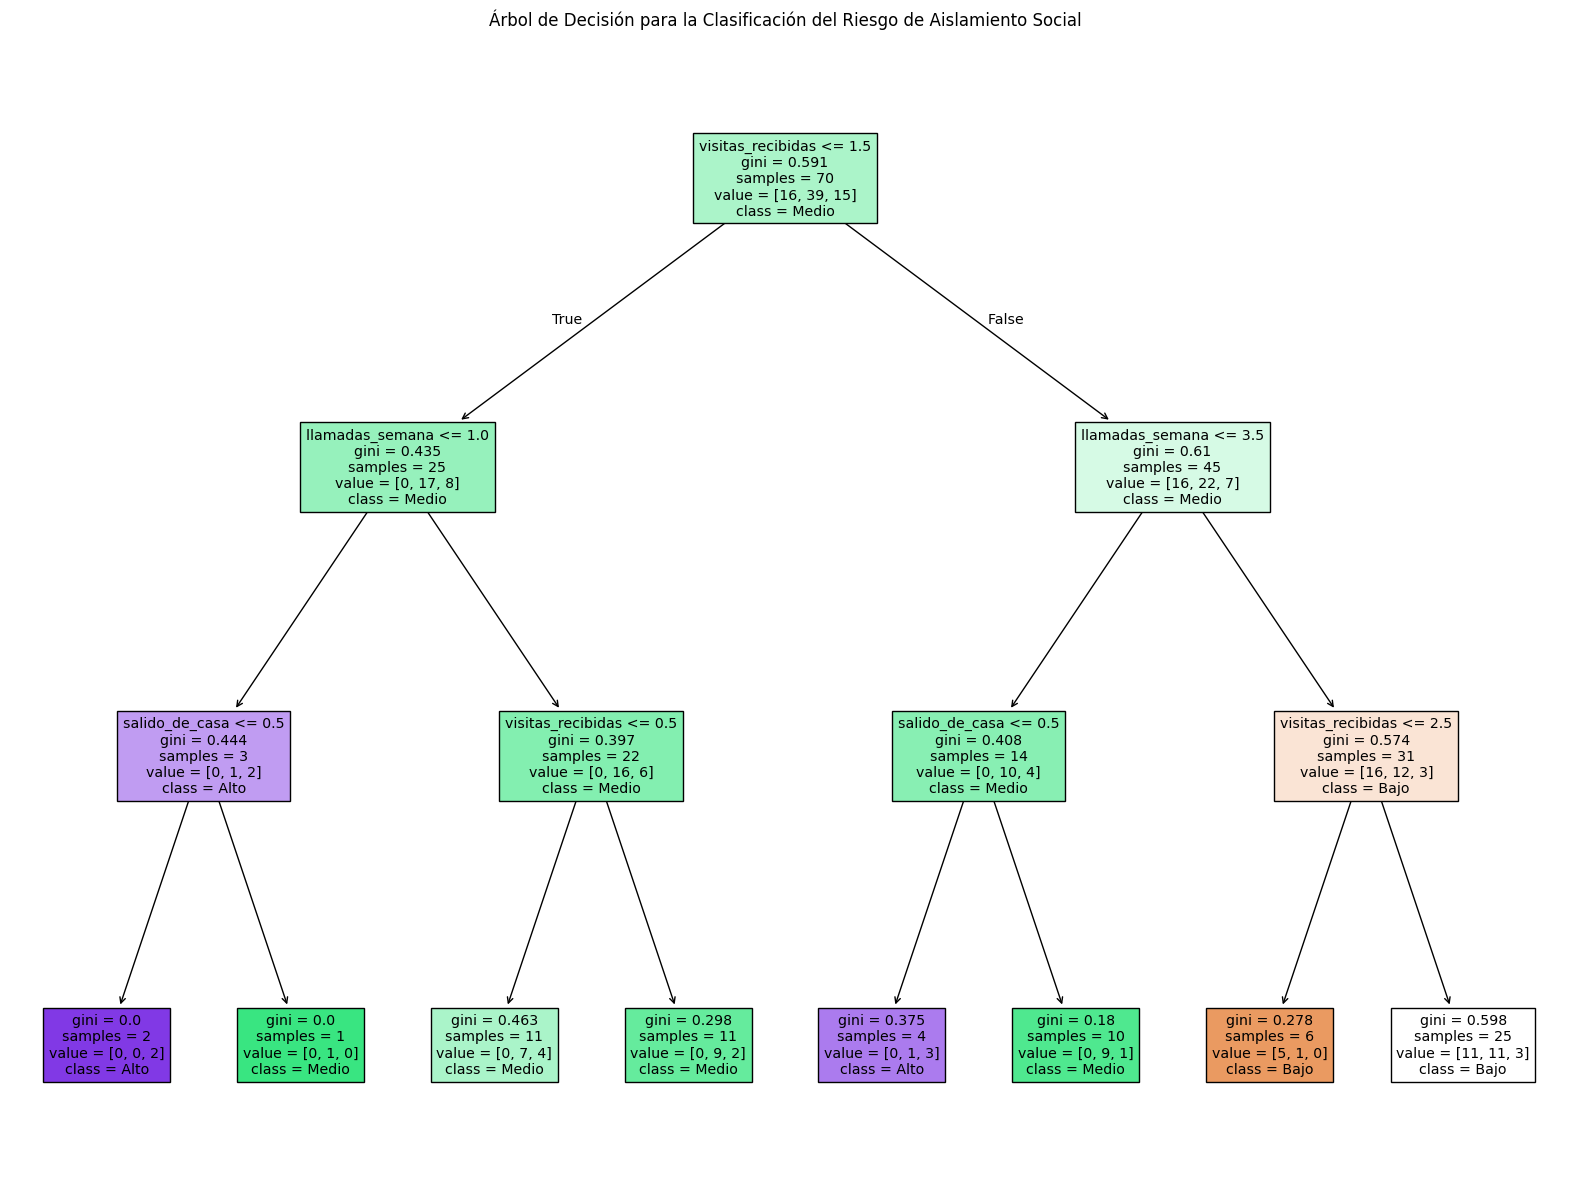

In [7]:
# Realizar predicciones en el conjunto de prueba
y_pred = dtree_model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=risk_mapping.keys())

print(f"Precisión del modelo: {accuracy:.2f}")
print("\nReporte de Clasificación:\n", report)

# Visualizar el Árbol de Decisión
fig = plt.figure(figsize=(20,15))
_ = plot_tree(dtree_model,
                   feature_names=X.columns,
                   class_names=list(risk_mapping.keys()),
                   filled=True)
plt.title("Árbol de Decisión para la Clasificación del Riesgo de Aislamiento Social")
plt.show()

## Enfoque 2: Algoritmo de Regresión para predecir el deterioro del estado de ánimo/salud

El segundo enfoque se centra en predecir cuántos días faltan para que el estado de ánimo o la salud del usuario decaiga si no recibe interacción social. Utilizaremos un algoritmo de regresión para esta tarea. Comenzaremos generando un dataset sintético que simule datos históricos de encuestas de bienestar y el nivel de interacción social.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Crear un dataset sintético para el problema de regresión
np.random.seed(42)
num_samples = 200

data_regression = {
    'interaccion_social_dias_ultimos_7': np.random.randint(0, 7, num_samples), # Días con interacción social en la última semana
    'horas_sueno_promedio': np.random.uniform(5, 9, num_samples), # Horas de sueño promedio
    'nivel_estres_percibido': np.random.randint(1, 10, num_samples), # Nivel de estrés (1-10)
    'dias_hasta_decaer_bienestar': np.random.randint(5, 30, num_samples) # Variable objetivo: días hasta que decaiga el bienestar
}

df_regression = pd.DataFrame(data_regression)

# Ajustar la variable objetivo de forma que menos interacción social, más estrés y menos sueño resulten en menos días hasta decaer
df_regression['dias_hasta_decaer_bienestar'] = (
    30
    - (df_regression['interaccion_social_dias_ultimos_7'] * 2)
    - (df_regression['nivel_estres_percibido'] * 1.5)
    + (df_regression['horas_sueno_promedio'] * 0.5)
    + np.random.normal(0, 5, num_samples) # Añadir ruido
)

df_regression['dias_hasta_decaer_bienestar'] = df_regression['dias_hasta_decaer_bienestar'].clip(5, 30).astype(int) # Asegurar que esté entre 5 y 30

# Mostrar las primeras filas del dataset
display(df_regression.head())

# Mostrar estadísticas descriptivas de la variable objetivo
display(df_regression['dias_hasta_decaer_bienestar'].describe())


,interaccion_social_dias_ultimos_7,horas_sueno_promedio,nivel_estres_percibido,dias_hasta_decaer_bienestar
0,6,6.182535,7,13
1,3,5.421977,9,14
2,4,6.826138,5,30
3,6,5.873762,1,25
4,2,6.666040,1,27


,dias_hasta_decaer_bienestar
count,200.000000
mean,18.865000
std,7.106991
min,5.000000
25%,13.000000
50%,18.500000
75%,24.000000
max,30.000000


### Preprocesamiento de Datos para Regresión

Dividimos el dataset en características (X) y la variable objetivo (y), y luego en conjuntos de entrenamiento y prueba.

In [9]:
# Definir las características (X) y la variable objetivo (y) para el modelo de regresión
X_reg = df_regression[['interaccion_social_dias_ultimos_7', 'horas_sueno_promedio', 'nivel_estres_percibido']]
y_reg = df_regression['dias_hasta_decaer_bienestar']

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

print("Dimensiones del conjunto de entrenamiento de regresión:", X_train_reg.shape, y_train_reg.shape)
print("Dimensiones del conjunto de prueba de regresión:", X_test_reg.shape, y_test_reg.shape)

Dimensiones del conjunto de entrenamiento de regresión: (140, 3) (140,)
Dimensiones del conjunto de prueba de regresión: (60, 3) (60,)


### Entrenamiento del Modelo de Regresión

Entrenamos un modelo de Regresión Lineal para predecir los días hasta el deterioro del bienestar.

In [ ]:
# Inicializar y entrenar el modelo de Regresión Lineal
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_reg, y_train_reg)

print("Modelo de Regresión Lineal entrenado.")
print("Coeficientes del modelo:", lin_reg_model.coef_)
print("Intercepto del modelo:", lin_reg_model.intercept_)


Modelo de Regresión Lineal entrenado.
Coeficientes del modelo: [-1.98602971 -0.4612782  -1.33943764]
Intercepto del modelo: 34.822547434280644


### Evaluación del Modelo de Regresión

Evaluamos el rendimiento del modelo en el conjunto de prueba utilizando métricas como el Error Cuadrático Medio (MSE) y el coeficiente de determinación (R²).

Error Cuadrático Medio (MSE): 25.18
Coeficiente de Determinación (R²): 0.50


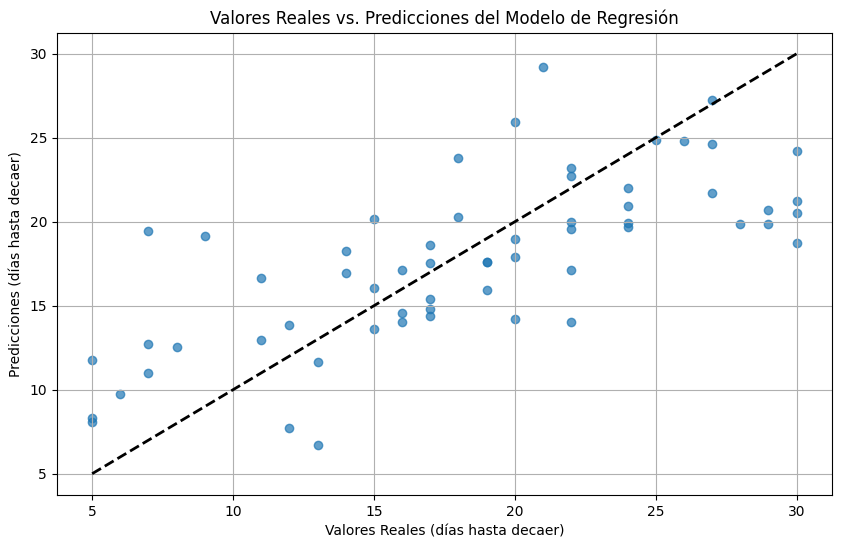

In [ ]:
# Realizar predicciones en el conjunto de prueba
y_pred_reg = lin_reg_model.predict(X_test_reg)

# Evaluar el modelo
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

# Visualizar las predicciones vs. los valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2)
plt.xlabel("Valores Reales (días hasta decaer)")
plt.ylabel("Predicciones (días hasta decaer)")
plt.title("Valores Reales vs. Predicciones del Modelo de Regresión")
plt.grid(True)
plt.show()


## Enfoque 3: Redes Neuronales para detección de anomalías en datos de sensores

El tercer enfoque utiliza Redes Neuronales para analizar series temporales de datos de sensores básicos del hogar (como el uso de luz o agua) y detectar anomalías. Para este ejemplo, crearemos un dataset sintético que simule el uso normal de un sensor y luego introduciremos algunas anomalías.

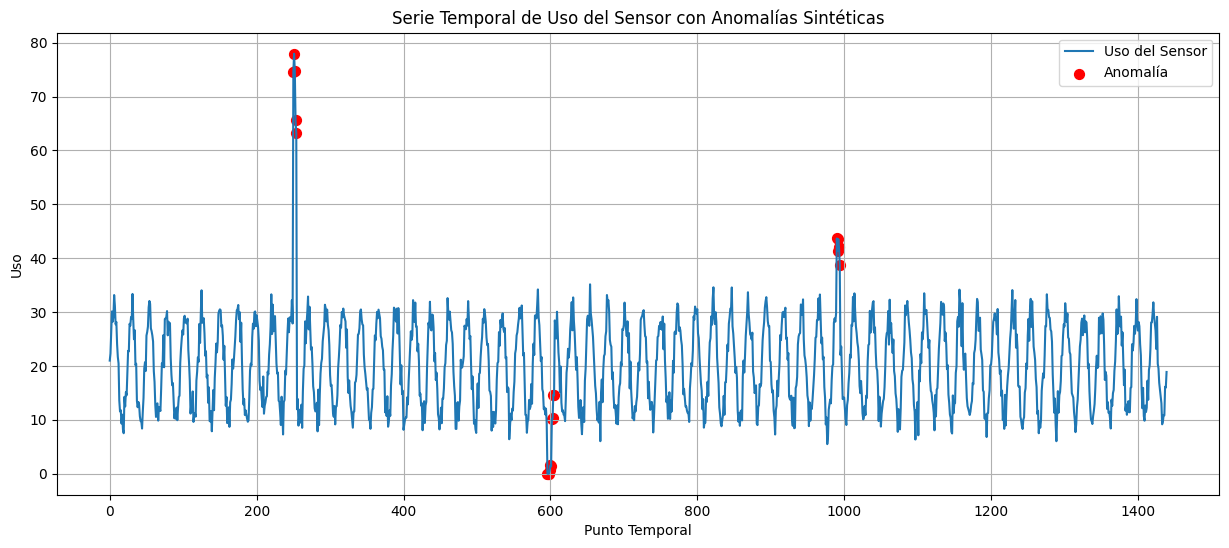

,usage,is_anomaly
0,20.993428,False
1,22.311662,False
2,26.295377,False
3,30.117128,False
4,28.191947,False


,usage,is_anomaly
1435,10.905902,False
1436,10.842364,False
1437,16.143623,False
1438,15.981950,False
1439,18.881565,False


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# Generar datos sintéticos de series temporales para un sensor (por ejemplo, uso de luz/agua)
np.random.seed(42)

# Datos normales: Patrón diario con algo de ruido
horas_dia = np.arange(0, 24, 0.5) # 48 puntos por día
num_dias = 30

normal_pattern = np.sin(horas_dia / 24 * 2 * np.pi * 2) * 10 + 20 # Dos picos de uso al día
normal_data = np.tile(normal_pattern, num_dias) + np.random.normal(0, 2, num_dias * len(horas_dia))

# Introducir algunas anomalías (por ejemplo, picos inusuales o caídas prolongadas)
anomalies = np.zeros_like(normal_data)

# Anomalia 1: Pico inusual
anomalies[len(horas_dia) * 5 + 10 : len(horas_dia) * 5 + 15] = 50 + np.random.normal(0, 3, 5)

# Anomalia 2: Caída prolongada (no uso)
anomalies[len(horas_dia) * 12 + 20 : len(horas_dia) * 12 + 30] = -20 + np.random.normal(0, 2, 10)

# Anomalia 3: Uso constante a horas inusuales
anomalies[len(horas_dia) * 20 + 30 : len(horas_dia) * 20 + 35] = 15 + np.random.normal(0, 1, 5)

sensor_data = normal_data + anomalies
sensor_data = np.maximum(0, sensor_data) # Asegurar valores no negativos

# Crear un DataFrame para la serie temporal
df_sensor = pd.DataFrame({'usage': sensor_data, 'is_anomaly': (anomalies != 0)})

# Visualizar la serie temporal con anomalías
plt.figure(figsize=(15, 6))
plt.plot(df_sensor['usage'], label='Uso del Sensor')
plt.scatter(df_sensor[df_sensor['is_anomaly']].index, df_sensor[df_sensor['is_anomaly']]['usage'], color='red', label='Anomalía', marker='o', s=50)
plt.title('Serie Temporal de Uso del Sensor con Anomalías Sintéticas')
plt.xlabel('Punto Temporal')
plt.ylabel('Uso')
plt.legend()
plt.grid(True)
plt.show()

display(df_sensor.head())
display(df_sensor.tail())


### Preprocesamiento de Datos para Redes Neuronales

Normalizamos los datos y preparamos el dataset para el entrenamiento de la red neuronal. En este caso, entrenaremos un Autoencoder, que aprenderá a reconstruir el comportamiento 'normal' de los datos. Las anomalías se detectarán por una alta 'error de reconstrucción'.

In [ ]:
# Escalar los datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_sensor[['usage']])

# Un Autoencoder se entrena solo con datos 'normales'
X_train_nn = data_scaled[~df_sensor['is_anomaly']]
X_test_nn = data_scaled # Usaremos todos los datos para probar la detección de anomalías

print("Dimensiones de los datos escalados para entrenamiento NN:", X_train_nn.shape)
print("Dimensiones de los datos escalados para prueba NN:", X_test_nn.shape)

Dimensiones de los datos escalados para entrenamiento NN: (1420, 1)
Dimensiones de los datos escalados para prueba NN: (1440, 1)


### Entrenamiento del Autoencoder

Definimos y entrenamos un Autoencoder. Este tipo de red neuronal está diseñada para aprender una representación eficiente (codificación) de los datos de entrada, de manera que pueda reconstruirlos a partir de esa representación. Al entrenar con solo datos 'normales', el autoencoder se volverá bueno en reconstruir patrones normales, pero tendrá un alto error de reconstrucción para anomalías.

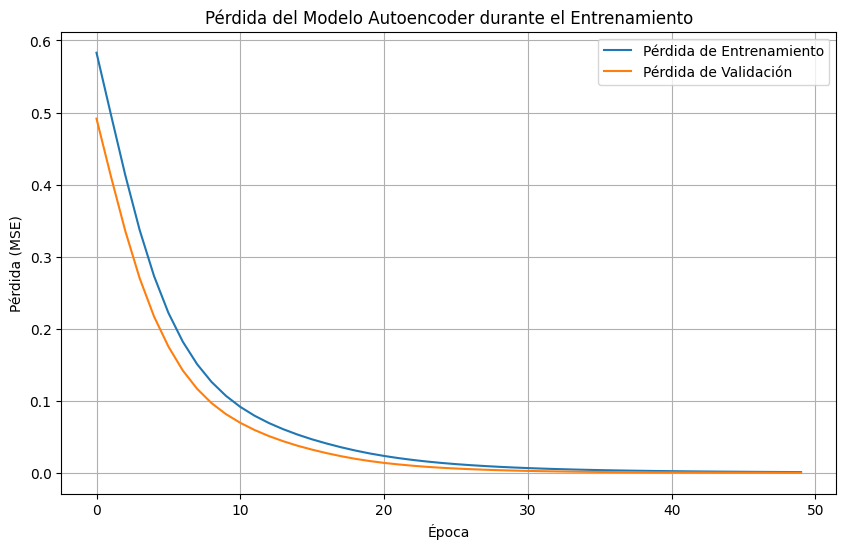

Autoencoder entrenado.


In [ ]:
# Definir la arquitectura del Autoencoder
input_dim = X_train_nn.shape[1]
encoding_dim = 1  # Dimensión del espacio latente

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation="relu")(input_layer)
decoder = Dense(input_dim, activation="linear")(encoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compilar el modelo
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Entrenar el Autoencoder con los datos normales
history = autoencoder.fit(X_train_nn, X_train_nn,
                          epochs=50,
                          batch_size=16,
                          shuffle=True,
                          validation_split=0.1,
                          verbose=0)

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida del Modelo Autoencoder durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()

print("Autoencoder entrenado.")

### Detección de Anomalías con el Autoencoder

Utilizamos el Autoencoder entrenado para reconstruir todos los datos (incluyendo las anomalías). Calculamos el error de reconstrucción (diferencia entre el original y la reconstrucción) y establecemos un umbral para clasificar los puntos con un error alto como anomalías.

### Optimización del Umbral de Detección de Anomalías

Para optimizar el umbral de detección y reducir los falsos positivos, en lugar de un umbral estadístico simple, utilizaremos un **umbral basado en percentiles**. Este método establece el umbral en un percentil alto (por ejemplo, el 99%) de los errores de reconstrucción calculados **únicamente sobre los datos de entrenamiento normales**. Esto asegura que el autoencoder sea muy sensible a cualquier desviación del patrón `normal` que ha aprendido, minimizando las alertas incorrectas para comportamientos rutinarios.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


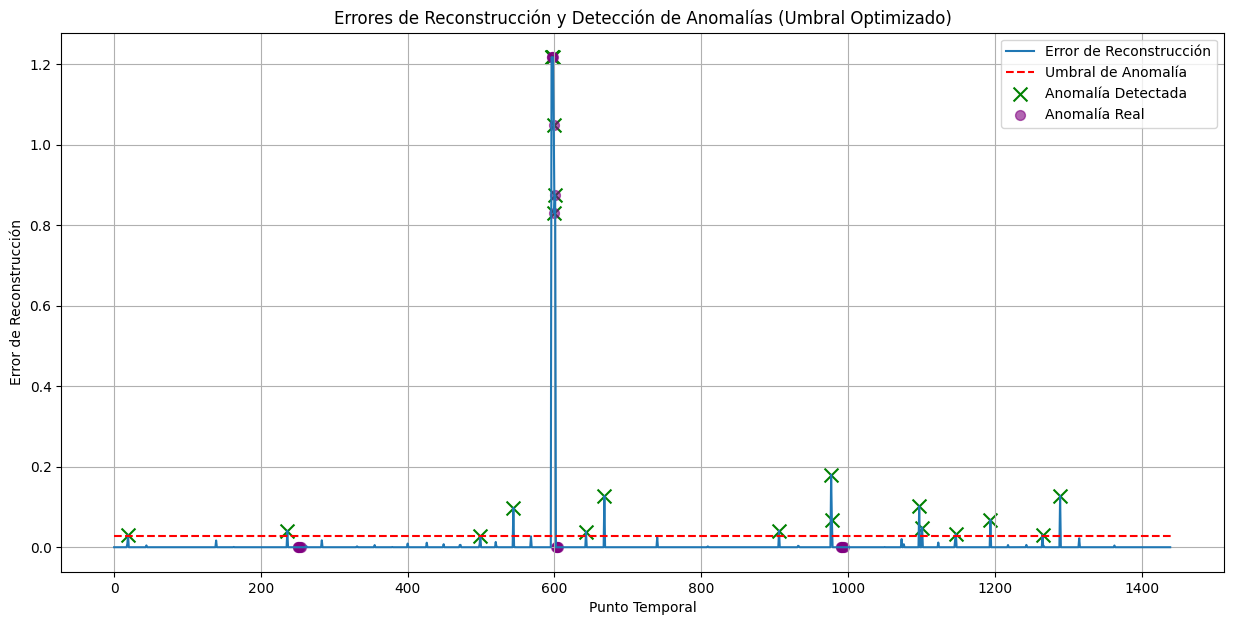

Umbral de Anomalía (Percentil 99 de datos normales): 0.0277
Total de puntos de datos: 1440
Anomalías reales: 20
Anomalías detectadas: 21

Matriz de Confusión:
 [[1405   15]
 [  14    6]]
Precisión: 0.29
Recall: 0.30
F1-Score: 0.29


In [ ]:
# Obtener las reconstrucciones de todos los datos (incluyendo anomalías)
reconstructions = autoencoder.predict(data_scaled)

# Calcular el error de reconstrucción para todos los puntos
mse_reconstruction = np.mean(np.power(data_scaled - reconstructions, 2), axis=1)

# Calcular las reconstrucciones y sus errores solo para los datos de entrenamiento (normales)
# Esto asegura que el umbral se base puramente en lo que el modelo considera 'normal'.
reconstructions_normal_train = autoencoder.predict(X_train_nn)
mse_reconstruction_normal_train = np.mean(np.power(X_train_nn - reconstructions_normal_train, 2), axis=1)

# Determinar el umbral basado en un percentil alto (e.g., 99%) de los errores de reconstrucción de los datos normales.
# Un percentil más alto reduce los falsos positivos (mayor precisión) a costa de potencialmente aumentar los falsos negativos (menor recall).
threshold = np.percentile(mse_reconstruction_normal_train, 99) # Usando el percentil 99 para reducir falsos positivos

# Identificar anomalías
df_sensor['reconstruction_error'] = mse_reconstruction
df_sensor['predicted_anomaly'] = df_sensor['reconstruction_error'] > threshold

# Visualizar los errores de reconstrucción y las anomalías detectadas
plt.figure(figsize=(15, 7))
plt.plot(df_sensor.index, df_sensor['reconstruction_error'], label='Error de Reconstrucción')
plt.hlines(threshold, xmin=0, xmax=len(df_sensor), colors='r', linestyles='dashed', label='Umbral de Anomalía')
plt.scatter(df_sensor[df_sensor['predicted_anomaly']].index, df_sensor[df_sensor['predicted_anomaly']]['reconstruction_error'], color='green', label='Anomalía Detectada', marker='x', s=100)
plt.scatter(df_sensor[df_sensor['is_anomaly']].index, df_sensor[df_sensor['is_anomaly']]['reconstruction_error'], color='purple', label='Anomalía Real', marker='o', s=50, alpha=0.6)
plt.title('Errores de Reconstrucción y Detección de Anomalías (Umbral Optimizado)')
plt.xlabel('Punto Temporal')
plt.ylabel('Error de Reconstrucción')
plt.legend()
plt.grid(True)
plt.show()

print(f"Umbral de Anomalía (Percentil 99 de datos normales): {threshold:.4f}")
print(f"Total de puntos de datos: {len(df_sensor)}")
print(f"Anomalías reales: {df_sensor['is_anomaly'].sum()}")
print(f"Anomalías detectadas: {df_sensor['predicted_anomaly'].sum()}")

# Opcional: Métricas de evaluación para detección de anomalías (si se tienen etiquetas reales)
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true_anomalies = df_sensor['is_anomaly']
y_pred_anomalies = df_sensor['predicted_anomaly']

print("\nMatriz de Confusión:\n", confusion_matrix(y_true_anomalies, y_pred_anomalies))
print(f"Precisión: {precision_score(y_true_anomalies, y_pred_anomalies):.2f}")
print(f"Recall: {recall_score(y_true_anomalies, y_pred_anomalies):.2f}")
print(f"F1-Score: {f1_score(y_true_anomalies, y_pred_anomalies):.2f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


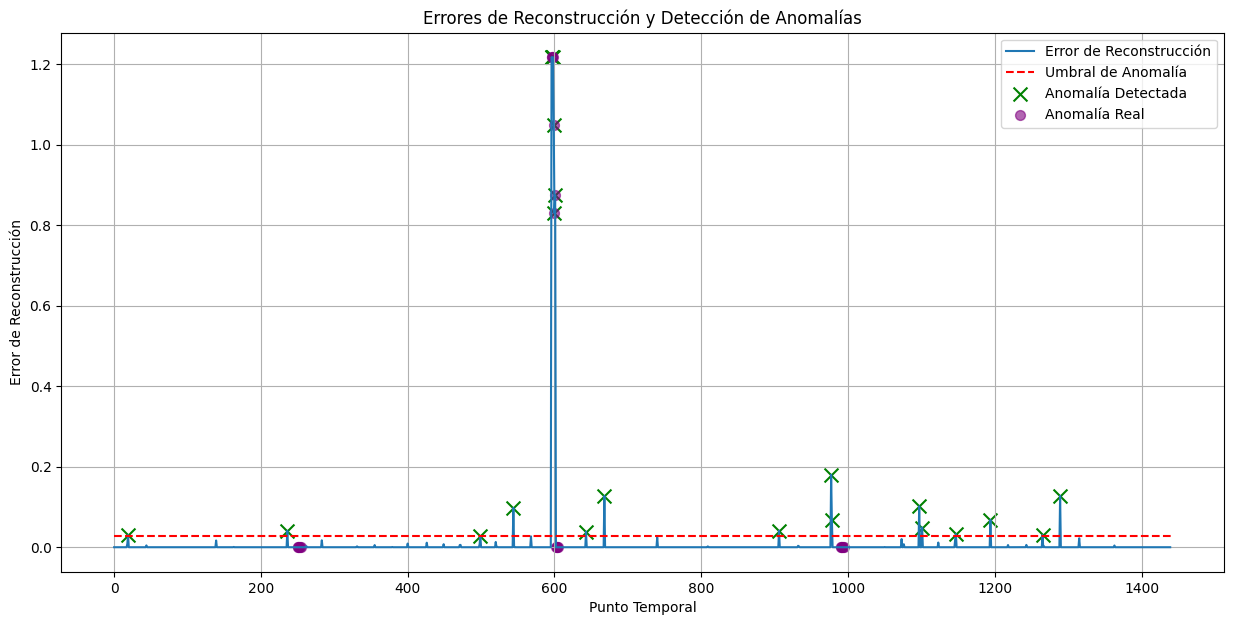

Umbral de Anomalía: 0.03
Total de puntos de datos: 1440
Anomalías reales: 20
Anomalías detectadas: 21

Matriz de Confusión:
 [[1405   15]
 [  14    6]]
Precisión: 0.29
Recall: 0.30
F1-Score: 0.29


In [ ]:
# Obtener las reconstrucciones de todos los datos
reconstructions = autoencoder.predict(data_scaled)

# Calcular el error de reconstrucción
mse_reconstruction = np.mean(np.power(data_scaled - reconstructions, 2), axis=1)

# Determinar un umbral para las anomalías (por ejemplo, percentil 95 o 99 del error de reconstrucción en datos 'normales')
# Para este ejemplo, usaremos un umbral simple basado en los errores de reconstrucción de los datos normales
threshold = np.mean(mse_reconstruction[~df_sensor['is_anomaly']]) + 3 * np.std(mse_reconstruction[~df_sensor['is_anomaly']])

# Identificar anomalías
df_sensor['reconstruction_error'] = mse_reconstruction
df_sensor['predicted_anomaly'] = df_sensor['reconstruction_error'] > threshold

# Visualizar los errores de reconstrucción y las anomalías detectadas
plt.figure(figsize=(15, 7))
plt.plot(df_sensor.index, df_sensor['reconstruction_error'], label='Error de Reconstrucción')
plt.hlines(threshold, xmin=0, xmax=len(df_sensor), colors='r', linestyles='dashed', label='Umbral de Anomalía')
plt.scatter(df_sensor[df_sensor['predicted_anomaly']].index, df_sensor[df_sensor['predicted_anomaly']]['reconstruction_error'], color='green', label='Anomalía Detectada', marker='x', s=100)
plt.scatter(df_sensor[df_sensor['is_anomaly']].index, df_sensor[df_sensor['is_anomaly']]['reconstruction_error'], color='purple', label='Anomalía Real', marker='o', s=50, alpha=0.6)
plt.title('Errores de Reconstrucción y Detección de Anomalías')
plt.xlabel('Punto Temporal')
plt.ylabel('Error de Reconstrucción')
plt.legend()
plt.grid(True)
plt.show()

print(f"Umbral de Anomalía: {threshold:.2f}")
print(f"Total de puntos de datos: {len(df_sensor)}")
print(f"Anomalías reales: {df_sensor['is_anomaly'].sum()}")
print(f"Anomalías detectadas: {df_sensor['predicted_anomaly'].sum()}")

# Opcional: Métricas de evaluación para detección de anomalías (si se tienen etiquetas reales)
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true_anomalies = df_sensor['is_anomaly']
y_pred_anomalies = df_sensor['predicted_anomaly']

print("\nMatriz de Confusión:\n", confusion_matrix(y_true_anomalies, y_pred_anomalies))
print(f"Precisión: {precision_score(y_true_anomalies, y_pred_anomalies):.2f}")
print(f"Recall: {recall_score(y_true_anomalies, y_pred_anomalies):.2f}")
print(f"F1-Score: {f1_score(y_true_anomalies, y_pred_anomalies):.2f}")
